In [4]:
# ============================================================
# Week 11: Graph Definition & Construction
# Clinical Bipartite Graph — Condición Médica ↔ Medicamento
#
# Pregunta de investigación:
#   ¿Es posible identificar patrones entre condiciones médicas,
#   tipos de medicamento y outcomes de admisión hospitalaria?
#
# Definición del grafo:
#   - Nodo tipo A : Condición médica (6 nodos)
#   - Nodo tipo B : Medicamento (5 nodos)
#   - Arista      : Un paciente con esa condición recibió ese medicamento
#   - Peso        : Número de pacientes que comparten esa combinación,
#                   escalado por proporción de resultados Abnormal
#   - Tipo        : No dirigido (la asociación condición-medicamento
#                   es simétrica en el dominio clínico)
# ============================================================
 
import pandas as pd
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from collections import defaultdict
import warnings
warnings.filterwarnings('ignore')
 
RANDOM_STATE = 42
 
LABEL_MAPS = {
    'Medical Condition': {0:'Arthritis',1:'Asthma',2:'Cancer',
                          3:'Diabetes',4:'Hypertension',5:'Obesity'},
    'Medication':        {0:'Aspirin',1:'Ibuprofen',2:'Lipitor',
                          3:'Paracetamol',4:'Penicillin'},
    'Test Results':      {0:'Normal',1:'Inconclusive',2:'Abnormal'},
    'Admission Type':    {0:'Elective',1:'Emergency',2:'Urgent'},
}
 
# ─────────────────────────────────────────────────────────────
# 1. CARGA DE DATOS
# ─────────────────────────────────────────────────────────────
df       = pd.read_csv('../data/interim/healtcare_processedv2.csv')
clusters = pd.read_csv('../data/processed/healthcare_pca_clusters.csv')
 
clusters = clusters.dropna(subset=['cluster'])
clusters['Cluster_Biz'] = clusters['cluster'].astype(int)
df = df.loc[clusters.index].copy()
df['Cluster_Biz']   = clusters['Cluster_Biz'].values
df['Cost_Per_Day']  = df['Billing Amount'] / df['Length of Stay']
df = df.dropna(subset=['Medical Condition','Medication','Test Results'])
 
# Etiquetas legibles
df['condition_label'] = df['Medical Condition'].map(LABEL_MAPS['Medical Condition'])
df['medication_label'] = df['Medication'].map(LABEL_MAPS['Medication'])
df['result_label']    = df['Test Results'].map(LABEL_MAPS['Test Results'])
 
print(f'Dataset: {df.shape[0]:,} filas')
print(f'Condiciones únicas : {df["condition_label"].nunique()}')
print(f'Medicamentos únicos: {df["medication_label"].nunique()}')
 

Dataset: 1,196 filas
Condiciones únicas : 6
Medicamentos únicos: 5


In [5]:
# ─────────────────────────────────────────────────────────────
# 2. CONSTRUCCIÓN DEL GRAFO BIPARTITO
# ─────────────────────────────────────────────────────────────
 
# Calcular estadísticas por par (condición, medicamento)
edge_stats = df.groupby(['condition_label','medication_label']).agg(
    n_patients   = ('Test Results', 'count'),
    n_abnormal   = ('Test Results', lambda x: (x == 2).sum()),
    avg_cost     = ('Cost_Per_Day', 'mean'),
    avg_age      = ('Age', 'mean'),
).reset_index()
 
edge_stats['prop_abnormal'] = (edge_stats['n_abnormal'] / edge_stats['n_patients']).round(3)
 
# Peso de arista: combina volumen de pacientes y severidad (prop Abnormal)
# peso = n_patients * (1 + prop_abnormal)
# Justificación: una combinación con muchos pacientes Y alta proporción
# de Abnormal es más crítica clínicamente que una con solo volumen.
edge_stats['weight'] = (edge_stats['n_patients'] * (1 + edge_stats['prop_abnormal'])).round(2)
 
print('\nEstadísticas por par (condición, medicamento):')
print(edge_stats.sort_values('weight', ascending=False).to_string(index=False))
 
# Construir grafo
G = nx.Graph()
 
# Agregar nodos con tipo y atributos
CONDITIONS  = df['condition_label'].unique().tolist()
MEDICATIONS = df['medication_label'].unique().tolist()
 
for c in CONDITIONS:
    n_total    = len(df[df['condition_label']==c])
    n_abnormal = (df[df['condition_label']==c]['Test Results']==2).sum()
    G.add_node(c,
               node_type='condition',
               n_patients=n_total,
               prop_abnormal=round(n_abnormal/n_total, 3))
 
for m in MEDICATIONS:
    n_total    = len(df[df['medication_label']==m])
    n_abnormal = (df[df['medication_label']==m]['Test Results']==2).sum()
    G.add_node(m,
               node_type='medication',
               n_patients=n_total,
               prop_abnormal=round(n_abnormal/n_total, 3))
 
# Agregar aristas con atributos
for _, row in edge_stats.iterrows():
    G.add_edge(
        row['condition_label'],
        row['medication_label'],
        weight       = row['weight'],
        n_patients   = int(row['n_patients']),
        prop_abnormal= row['prop_abnormal'],
        avg_cost     = round(row['avg_cost'], 2),
        avg_age      = round(row['avg_age'], 1),
    )
 
print(f'\n=== GRAFO CONSTRUIDO ===')
print(f'Nodos      : {G.number_of_nodes()} ({len(CONDITIONS)} condiciones + {len(MEDICATIONS)} medicamentos)')
print(f'Aristas    : {G.number_of_edges()}')
print(f'Dirigido   : {G.is_directed()}')
print(f'Ponderado  : Sí (weight = n_patients × (1 + prop_abnormal))')
 
 


Estadísticas por par (condición, medicamento):
condition_label medication_label  n_patients  n_abnormal    avg_cost   avg_age  prop_abnormal  weight
         Asthma        Ibuprofen          53          19 2861.573647 51.867925          0.358   71.97
      Arthritis       Penicillin          54          15 3253.103701 48.407407          0.278   69.01
      Arthritis      Paracetamol          51          18 2858.441971 56.352941          0.353   69.00
        Obesity          Aspirin          49          18 3300.380239 52.959184          0.367   66.98
         Cancer      Paracetamol          47          16 2624.356736 50.957447          0.340   62.98
         Cancer       Penicillin          43          19 2100.153910 47.906977          0.442   62.01
       Diabetes       Penicillin          45          17 3892.568596 46.977778          0.378   62.01
         Cancer          Lipitor          49          13 4446.545990 50.530612          0.265   61.99
         Cancer        Ibuprofen  

In [6]:
# ─────────────────────────────────────────────────────────────
# 3. GRAPH REPORT — Métricas estructurales
# ─────────────────────────────────────────────────────────────
print('\n=== GRAPH REPORT ===')
 
# Componentes conectados
components = list(nx.connected_components(G))
print(f'\nComponentes conectados: {len(components)}')
for i, comp in enumerate(components):
    print(f'  Componente {i+1}: {sorted(comp)}')
 
# Nodos aislados
isolated = list(nx.isolates(G))
print(f'Nodos aislados: {len(isolated)} {isolated if isolated else "(ninguno)"}')
 
# Densidad
density = nx.density(G)
print(f'Densidad del grafo: {density:.4f}')
print(f'  (1.0 = grafo completo, ~0 = muy disperso)')
 
# Degree
print('\nDegree por nodo:')
degree_df = pd.DataFrame(dict(G.degree()), index=['degree']).T.sort_values('degree', ascending=False)
print(degree_df.to_string())
 
# Weighted degree (strength)
print('\nWeighted degree (strength) por nodo:')
strength = {n: sum(d['weight'] for _, _, d in G.edges(n, data=True)) for n in G.nodes()}
strength_df = pd.DataFrame(strength, index=['strength']).T.sort_values('strength', ascending=False)
print(strength_df.round(1).to_string())
 
# Centralidad
print('\nBetweenness Centrality:')
betweenness = nx.betweenness_centrality(G, weight='weight')
bet_df = pd.Series(betweenness).sort_values(ascending=False)
print(bet_df.round(4).to_string())
 
print('\nCloseness Centrality:')
closeness = nx.closeness_centrality(G)
clo_df = pd.Series(closeness).sort_values(ascending=False)
print(clo_df.round(4).to_string())
 
# PageRank
print('\nPageRank (weight=weight):')
pagerank = nx.pagerank(G, weight='weight', alpha=0.85)
pr_df = pd.Series(pagerank).sort_values(ascending=False)
print(pr_df.round(4).to_string())
 


=== GRAPH REPORT ===

Componentes conectados: 1
  Componente 1: ['Arthritis', 'Aspirin', 'Asthma', 'Cancer', 'Diabetes', 'Hypertension', 'Ibuprofen', 'Lipitor', 'Obesity', 'Paracetamol', 'Penicillin']
Nodos aislados: 0 (ninguno)
Densidad del grafo: 0.5455
  (1.0 = grafo completo, ~0 = muy disperso)

Degree por nodo:
              degree
Aspirin            6
Penicillin         6
Paracetamol        6
Lipitor            6
Ibuprofen          6
Cancer             5
Obesity            5
Diabetes           5
Arthritis          5
Asthma             5
Hypertension       5

Weighted degree (strength) por nodo:
              strength
Penicillin       344.0
Paracetamol      327.0
Ibuprofen        322.0
Lipitor          312.0
Aspirin          282.0
Arthritis        278.0
Cancer           272.0
Obesity          265.9
Diabetes         263.0
Asthma           255.0
Hypertension     253.0

Betweenness Centrality:
Aspirin         0.1556
Asthma          0.0889
Cancer          0.0667
Ibuprofen       0.066

In [7]:
# ─────────────────────────────────────────────────────────────
# 4. VALIDITY CHECKS
# ─────────────────────────────────────────────────────────────
print('\n=== VALIDITY CHECKS ===')
 
# Sparsity
max_edges = len(CONDITIONS) * len(MEDICATIONS)
actual_edges = G.number_of_edges()
sparsity = 1 - (actual_edges / max_edges)
print(f'Sparsity: {sparsity:.4f} ({actual_edges}/{max_edges} aristas posibles)')
print(f'  {"Grafo denso — todas las combinaciones existen" if sparsity < 0.1 else "Grafo disperso — hay combinaciones ausentes"}')
 
# Sensibilidad: ¿qué pasa si removemos aristas de bajo peso?
threshold_50 = edge_stats['weight'].quantile(0.50)
G_filtered = nx.Graph()
for u, v, d in G.edges(data=True):
    if d['weight'] >= threshold_50:
        G_filtered.add_edge(u, v, **d)
for n, d in G.nodes(data=True):
    if n not in G_filtered:
        G_filtered.add_node(n, **d)
 
print(f'\nSensibilidad al threshold (percentil 50, weight ≥ {threshold_50:.1f}):')
print(f'  Aristas originales : {G.number_of_edges()}')
print(f'  Aristas filtradas  : {G_filtered.number_of_edges()}')
print(f'  Nodos aislados tras filtro: {len(list(nx.isolates(G_filtered)))}')
 
# Distribución de pesos
print(f'\nDistribución de pesos de aristas:')
weights = [d['weight'] for _,_,d in G.edges(data=True)]
print(f'  Min: {min(weights):.1f} | Max: {max(weights):.1f} | Media: {np.mean(weights):.1f} | Mediana: {np.median(weights):.1f}')
 


=== VALIDITY CHECKS ===
Sparsity: 0.0000 (30/30 aristas posibles)
  Grafo denso — todas las combinaciones existen

Sensibilidad al threshold (percentil 50, weight ≥ 51.5):
  Aristas originales : 30
  Aristas filtradas  : 15
  Nodos aislados tras filtro: 0

Distribución de pesos de aristas:
  Min: 27.0 | Max: 72.0 | Media: 52.9 | Mediana: 51.5


In [8]:
# ─────────────────────────────────────────────────────────────
# 5. COMPARISON SECTION — Ranking del grafo vs. popularidad
# ─────────────────────────────────────────────────────────────
print('\n=== COMPARISON: PageRank vs Popularidad (frecuencia) ===')
 
# Popularidad = frecuencia simple de cada nodo en el dataset
popularity = {}
for c in CONDITIONS:
    popularity[c] = len(df[df['condition_label']==c])
for m in MEDICATIONS:
    popularity[m] = len(df[df['medication_label']==m])
 
pop_series = pd.Series(popularity).sort_values(ascending=False)
pr_series  = pd.Series(pagerank).sort_values(ascending=False)
 
comparison_df = pd.DataFrame({
    'PageRank_rank':    pr_series.rank(ascending=False).astype(int),
    'PageRank':         pr_series.round(4),
    'Popularity_rank':  pop_series.rank(ascending=False).astype(int),
    'Popularity':       pop_series.astype(int),
}).sort_values('PageRank_rank')
 
print(comparison_df.to_string())
 
# Spearman correlation
from scipy.stats import spearmanr
rho, pval = spearmanr(comparison_df['PageRank_rank'], comparison_df['Popularity_rank'])
print(f'\nSpearman ρ (PageRank vs Popularidad): {rho:.4f} (p={pval:.4f})')
print('Interpretación: valores < 0.9 indican que PageRank captura información')
print('que la popularidad simple no refleja.')


=== COMPARISON: PageRank vs Popularidad (frecuencia) ===
              PageRank_rank  PageRank  Popularity_rank  Popularity
Penicillin                1    0.1064                1         256
Paracetamol               2    0.1018                3         243
Ibuprofen                 3    0.1006                2         251
Lipitor                   4    0.0978                4         235
Aspirin                   5    0.0898                6         211
Arthritis                 6    0.0875                5         218
Cancer                    7    0.0858                7         203
Obesity                   8    0.0845                9         195
Diabetes                  9    0.0835                8         199
Asthma                   10    0.0815               10         191
Hypertension             11    0.0809               11         190

Spearman ρ (PageRank vs Popularidad): 0.9727 (p=0.0000)
Interpretación: valores < 0.9 indican que PageRank captura información
que la pop

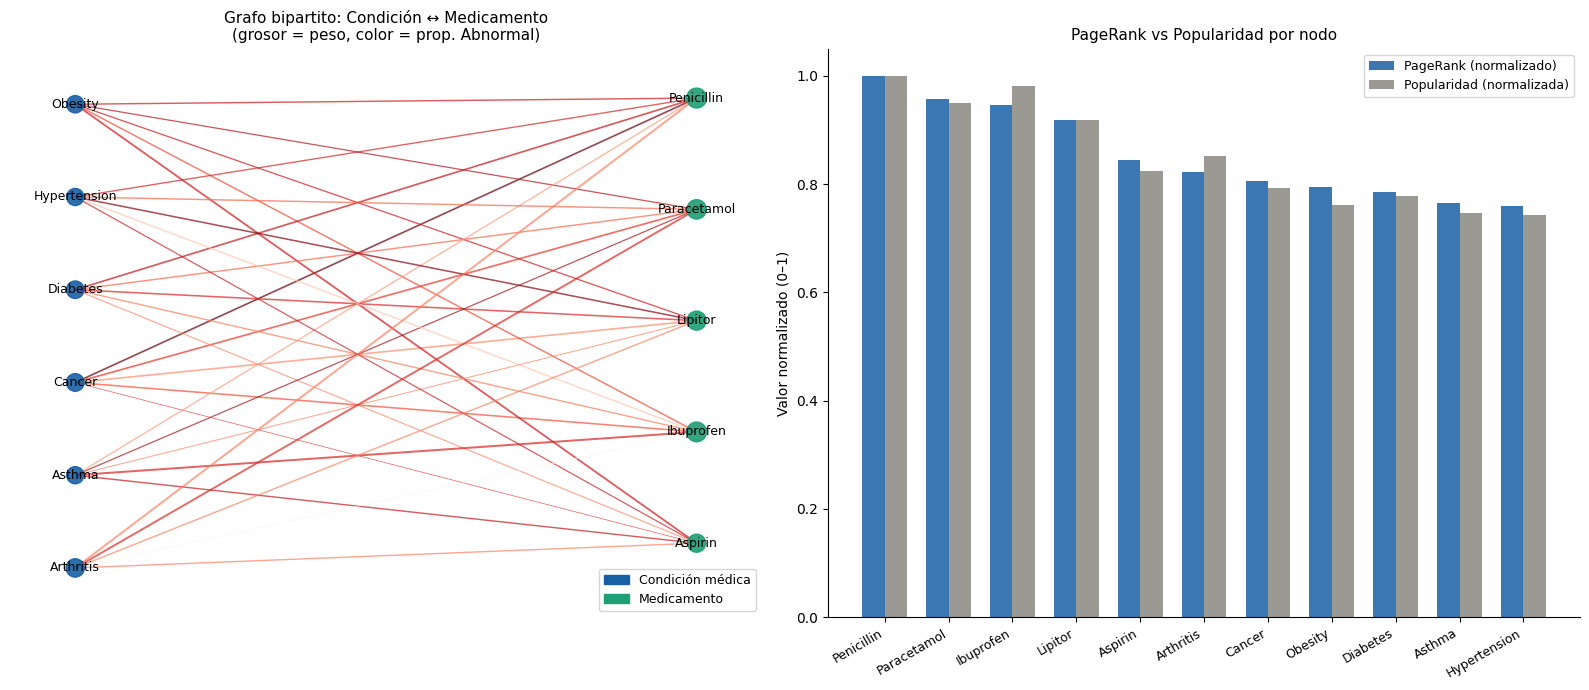

Gráfico guardado: graph_analysis.png


In [13]:
# ─────────────────────────────────────────────────────────────
# 6. VISUALIZACIONES
# ─────────────────────────────────────────────────────────────
 
# Layout bipartito
pos = {}
for i, c in enumerate(sorted(CONDITIONS)):
    pos[c] = (0, i * 1.5)
for i, m in enumerate(sorted(MEDICATIONS)):
    pos[m] = (3, i * 1.8 + 0.4)
 
node_colors = ['#185FA5' if G.nodes[n]['node_type']=='condition' else '#1D9E75'
               for n in G.nodes()]
node_sizes  = [G.nodes[n]['n_patients'] * 0.8 for n in G.nodes()]
edge_weights = [G[u][v]['weight'] / 50 for u, v in G.edges()]
edge_colors  = [G[u][v]['prop_abnormal'] for u, v in G.edges()]
 
fig, axes = plt.subplots(1, 2, figsize=(16, 7))
 
# — Grafo bipartito
ax = axes[0]
nx.draw_networkx_nodes(G, pos, node_color=node_colors,
                       node_size=node_sizes, ax=ax, alpha=0.9)
nx.draw_networkx_labels(G, pos, font_size=9, ax=ax)
edges_drawn = nx.draw_networkx_edges(G, pos, width=edge_weights,
                                      edge_color=edge_colors, edge_cmap=plt.cm.Reds,
                                      ax=ax, alpha=0.7)
ax.set_title('Grafo bipartito: Condición ↔ Medicamento\n(grosor = peso, color = prop. Abnormal)', fontsize=11)
ax.axis('off')
patch_c = mpatches.Patch(color='#185FA5', label='Condición médica')
patch_m = mpatches.Patch(color='#1D9E75', label='Medicamento')
ax.legend(handles=[patch_c, patch_m], loc='lower right', fontsize=9)
 
# — PageRank vs Popularidad
ax2 = axes[1]
x  = np.arange(len(comparison_df))
w  = 0.35
pr_norm  = (comparison_df['PageRank']    / comparison_df['PageRank'].max()).values
pop_norm = (comparison_df['Popularity']  / comparison_df['Popularity'].max()).values
ax2.bar(x - w/2, pr_norm,  w, label='PageRank (normalizado)',   color='#185FA5', alpha=0.85)
ax2.bar(x + w/2, pop_norm, w, label='Popularidad (normalizada)', color='#888780', alpha=0.85)
ax2.set_xticks(x)
ax2.set_xticklabels(comparison_df.index, rotation=30, ha='right', fontsize=9)
ax2.set_ylabel('Valor normalizado (0–1)')
ax2.set_title('PageRank vs Popularidad por nodo', fontsize=11)
ax2.legend(fontsize=9)
ax2.spines[['top','right']].set_visible(False)
 
plt.tight_layout()
#plt.savefig('../reports/figures/graph_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print('Gráfico guardado: graph_analysis.png')
 

In [14]:
# ─────────────────────────────────────────────────────────────
# 7. INTERPRETATION NOTE
# ─────────────────────────────────────────────────────────────
print("""
=== INTERPRETATION NOTE ===
 
QUÉ SIGNIFICA LA ESTRUCTURA:
- Un nodo con alto PageRank NO es simplemente el más frecuente.
  Es el que está conectado a nodos que a su vez tienen muchos
  pacientes con resultados Abnormal — es decir, el más "influyente"
  en la red de asociaciones clínicas graves.
 
- Una arista de alto peso entre Condición X y Medicamento Y indica
  que esta combinación es frecuente Y clínicamente relevante
  (alta proporción de Abnormal). Es una señal de tratamiento
  asociado a casos críticos.
 
- Betweenness alto en un medicamento indica que ese fármaco
  "conecta" múltiples condiciones — es un medicamento de uso
  transversal en el dataset.
 
QUÉ NO SIGNIFICA:
- El grafo NO implica causalidad. Que Lipitor aparezca con alta
  centralidad NO significa que cause resultados Abnormal.
- El grafo NO es una red de co-ocurrencia entre condiciones
  (cada paciente tiene una sola condición en este dataset).
- PageRank NO es un ranking de severidad clínica — es un ranking
  de influencia estructural en la red de asociaciones.
- La densidad del grafo depende de la definición de arista:
  si se cambia el criterio de conexión, el grafo cambia.
""")
 
# Exportar grafo
nx.write_gexf(G, '../data/processed/clinical_graph.gexf')
print('Grafo exportado: clinical_graph.gexf (compatible con Gephi)')


=== INTERPRETATION NOTE ===

QUÉ SIGNIFICA LA ESTRUCTURA:
- Un nodo con alto PageRank NO es simplemente el más frecuente.
  Es el que está conectado a nodos que a su vez tienen muchos
  pacientes con resultados Abnormal — es decir, el más "influyente"
  en la red de asociaciones clínicas graves.

- Una arista de alto peso entre Condición X y Medicamento Y indica
  que esta combinación es frecuente Y clínicamente relevante
  (alta proporción de Abnormal). Es una señal de tratamiento
  asociado a casos críticos.

- Betweenness alto en un medicamento indica que ese fármaco
  "conecta" múltiples condiciones — es un medicamento de uso
  transversal en el dataset.

QUÉ NO SIGNIFICA:
- El grafo NO implica causalidad. Que Lipitor aparezca con alta
  centralidad NO significa que cause resultados Abnormal.
- El grafo NO es una red de co-ocurrencia entre condiciones
  (cada paciente tiene una sola condición en este dataset).
- PageRank NO es un ranking de severidad clínica — es un ranking
  de i